Уже идёт весна, и ваш руководитель курса по питону Николай трясётся под одеялом, т.к. у него аллергия на цветение берёзы. Уже скоро будут чесаться глаза и потечёт ручей...


Помогите ему собрать новую аптечку, чтобы пережить апрель и май :)

# Часть 1. Анализ датасетов..

На диске в папке "Домашние задания" лежат три таблички в формате csv с товарами в разных аптеках.

Загрузи их в этот ноутбук и изучи. Ответь на следующие вопросы:
- Какие есть столбцы в этих датафреймах?
- Сколько значений в каждом датафрейме? Есть ли повторы внутри каждого датафрейма и между датафреймами?
- Все ли ячейки заполнены? Если нет, можем ли мы их заполнить?

In [1]:
import re
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA_DIR = Path('.')


def read_csv_safely(file_name: str) -> pd.DataFrame:
    path = DATA_DIR / file_name
    if not path.exists():
        raise FileNotFoundError(f'Файл {file_name} не найден рядом с ноутбуком')

    data = pd.read_csv(path)
    unnamed_columns = [column for column in data.columns if str(column).startswith('Unnamed')]
    if unnamed_columns:
        data = data.drop(columns=unnamed_columns)
    return data


pharmacy1_raw = read_csv_safely('pharmacy1.csv')
pharmacy2_raw = read_csv_safely('pharmacy2.csv')
pharmacy3_raw = read_csv_safely('pharmacy3.csv')

pharmacy1_raw.head()

,Наименование,Магазин № 3,Магазин № 4,Магазин № 5,Магазин № 6,Магазин № 7,Магазин № 8,Магазин № 9
0,"Меновазин, раствор для наружного применения сп...",NaN,NaN,41.0,35.0,NaN,36.0,NaN
1,"Супрастин, 25 мг, таблетки, 20 шт.",158.0,159.0,NaN,NaN,159.0,159.0,159.0
2,"Акридерм, 0.05%, мазь для наружного применения...",98.0,98.0,98.0,98.0,NaN,98.0,98.0
3,"Ацикловир-Акрихин, 200 мг, таблетки, 20 шт.",103.0,NaN,NaN,NaN,NaN,103.0,103.0
4,"Синафлан-Акрихин, 0.025%, мазь для наружного п...",108.0,108.0,115.0,NaN,NaN,108.0,NaN


In [2]:
def clean_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    value = str(value).replace(',', '.')
    match = re.search(r'\d+(?:\.\d+)?', value)
    return float(match.group()) if match else np.nan


def describe_dataframe(name: str, data: pd.DataFrame) -> None:
    print(f'\n{name}')
    print('-' * len(name))
    print('Столбцы:', list(data.columns))
    print('Размер:', data.shape)
    print('Полных дубликатов строк:', data.duplicated().sum())
    print('Пропуски по столбцам:')
    print(data.isna().sum())


for name, data in [
    ('pharmacy1_raw', pharmacy1_raw),
    ('pharmacy2_raw', pharmacy2_raw),
    ('pharmacy3_raw', pharmacy3_raw),
]:
    describe_dataframe(name, data)

def normalize_text(text):
    text = str(text).lower().replace('ё', 'е')
    text = re.sub(r'[^а-яa-z0-9]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

name_sets = {
    'pharmacy1': set(pharmacy1_raw['Наименование'].map(normalize_text)),
    'pharmacy2': set(pharmacy2_raw['Наименование'].map(normalize_text)),
    'pharmacy3': set(pharmacy3_raw['Наименование'].map(normalize_text)),
}

print('\nПересечения нормализованных названий')
for left, right in itertools.combinations(name_sets, 2):
    print(f'{left} & {right}: {len(name_sets[left] & name_sets[right])}')
print(f'Во всех трёх: {len(name_sets["pharmacy1"] & name_sets["pharmacy2"] & name_sets["pharmacy3"])}')


pharmacy1_raw
-------------
Столбцы: ['Наименование', 'Магазин № 3', 'Магазин № 4', 'Магазин № 5', 'Магазин № 6', 'Магазин № 7', 'Магазин № 8', 'Магазин № 9']
Размер: (598, 8)
Полных дубликатов строк: 39
Пропуски по столбцам:
Наименование      0
Магазин № 3     505
Магазин № 4     476
Магазин № 5     498
Магазин № 6     511
Магазин № 7     526
Магазин № 8     527
Магазин № 9     538
dtype: int64

pharmacy2_raw
-------------
Столбцы: ['Наименование', 'Цена', 'Производитель']
Размер: (164, 3)
Полных дубликатов строк: 0
Пропуски по столбцам:
Наименование     0
Цена             0
Производитель    0
dtype: int64

pharmacy3_raw
-------------
Столбцы: ['Наименование', 'Цена', 'Производитель']
Размер: (93, 3)
Полных дубликатов строк: 0
Пропуски по столбцам:
Наименование     0
Цена             4
Производитель    0
dtype: int64

Пересечения нормализованных названий
pharmacy1 & pharmacy2: 0
pharmacy1 & pharmacy3: 0
pharmacy2 & pharmacy3: 4
Во всех трёх: 0


In [3]:

store_columns = [column for column in pharmacy1_raw.columns if column.startswith('Магазин')]

pharmacy1_long = pharmacy1_raw.melt(
    id_vars='Наименование',
    value_vars=store_columns,
    var_name='Магазин',
    value_name='Цена',
)
pharmacy1_long['Цена'] = pharmacy1_long['Цена'].map(clean_price)
pharmacy1_long['Аптека'] = 'Аптека 1'
pharmacy1_long['Производитель'] = np.nan

pharmacy2 = pharmacy2_raw.copy()
pharmacy2['Цена'] = pharmacy2['Цена'].map(clean_price)
pharmacy2['Аптека'] = 'Аптека 2'
pharmacy2['Магазин'] = 'Аптека 2'

pharmacy3 = pharmacy3_raw.copy()
pharmacy3['Цена'] = pharmacy3['Цена'].map(clean_price)
pharmacy3['Аптека'] = 'Аптека 3'
pharmacy3['Магазин'] = 'Аптека 3'

all_prices = pd.concat(
    [
        pharmacy1_long[['Наименование', 'Цена', 'Аптека', 'Магазин', 'Производитель']],
        pharmacy2[['Наименование', 'Цена', 'Аптека', 'Магазин', 'Производитель']],
        pharmacy3[['Наименование', 'Цена', 'Аптека', 'Магазин', 'Производитель']],
    ],
    ignore_index=True,
)

all_prices_with_price = all_prices.dropna(subset=['Цена']).copy()

print('Единый датасет:', all_prices.shape)
print('Строк с известной ценой:', all_prices_with_price.shape)
all_prices_with_price.head()

Единый датасет: (4443, 5)
Строк с известной ценой: (858, 5)


,Наименование,Цена,Аптека,Магазин,Производитель
1,"Супрастин, 25 мг, таблетки, 20 шт.",158.0,Аптека 1,Магазин № 3,NaN
2,"Акридерм, 0.05%, мазь для наружного применения...",98.0,Аптека 1,Магазин № 3,NaN
3,"Ацикловир-Акрихин, 200 мг, таблетки, 20 шт.",103.0,Аптека 1,Магазин № 3,NaN
4,"Синафлан-Акрихин, 0.025%, мазь для наружного п...",108.0,Аптека 1,Магазин № 3,NaN
6,"Цетрин, 10 мг, таблетки, покрытые пленочной об...",167.0,Аптека 1,Магазин № 3,NaN


**Ответ по части 1.**

В `pharmacy1` есть столбец `Наименование` и несколько столбцов магазинов (`Магазин № 3` ... `Магазин № 9`), поэтому этот файл хранит цены в широком формате: одна строка — товар, отдельные столбцы — магазины.

В `pharmacy2` и `pharmacy3` есть столбцы `Наименование`, `Цена`, `Производитель`. Эти файлы уже ближе к длинному формату: одна строка — товар в аптеке.

Полные дубликаты строк внутри датафреймов почти неинформативны для сравнения между файлами, потому что структура файлов разная. Поэтому для пересечений между аптеками корректнее сравнивать нормализованные названия или специально выделенные признаки товара.

Пропуски есть в первую очередь в `pharmacy1`: пустая цена в конкретном магазине означает, что товара там нет или цена неизвестна. Заполнять такие пропуски средним/медианой некорректно, потому что мы искусственно создадим цену там, где её не было. Для визуализаций и сравнения цен такие строки лучше исключать, а для анализа наличия — считать пропуск как отсутствие товара в магазине.

# Часть 2. Визуализация..

Построй графики:

1. `histplot` распределения цен на лекарства в аптеках (по всем трём файлам сразу) с медианой, средним и kde.
2. `violinplot` для цен в аптеках (и отдельных магазинах).
3. `boxplot` для цен аптеках (и отдельных магазинах).
4. попарные `violinplot`'ы по сетям аптек (получается, 3 штуки - 1 и 2 файлы, 2 и 3 файлы, 1 и 3 файлы)
5. зависимость между производителем лекарства и его ценой.
6. круговую диаграмму по количеству (не по ценам!) лекарств в аптеках (и отдельных магазинах)
7. кривую с ценами товаров и оконным сглаживанием на 3, 5, 7 или 10 точек: сначала отсортируй цены товаров во всех аптеках (и по отдельности), потом построй сглаженную кривую.

Не забудь:

- подписать оси
- подписать название
- сохранять информативность графиков.

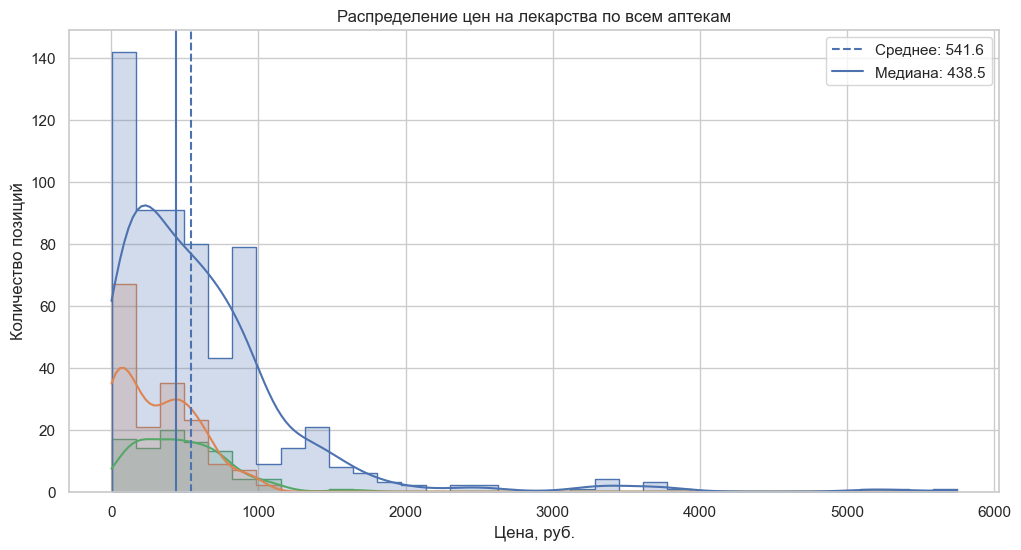

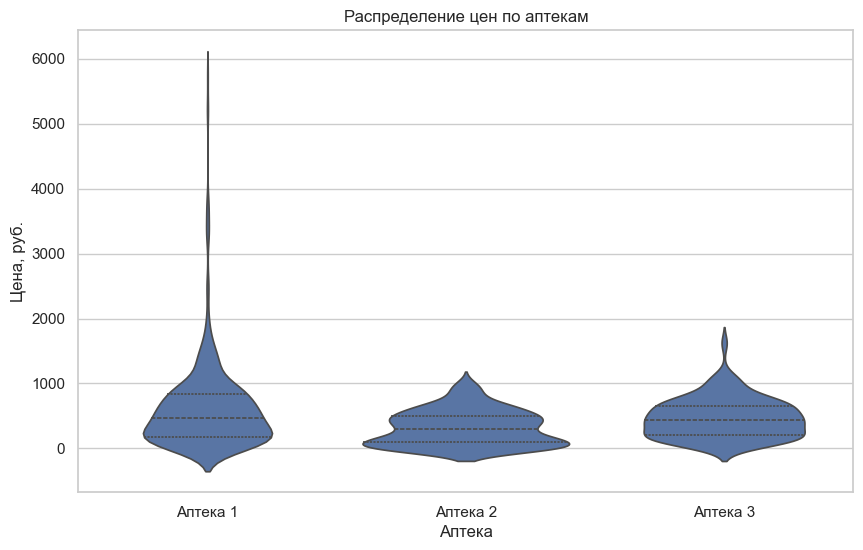

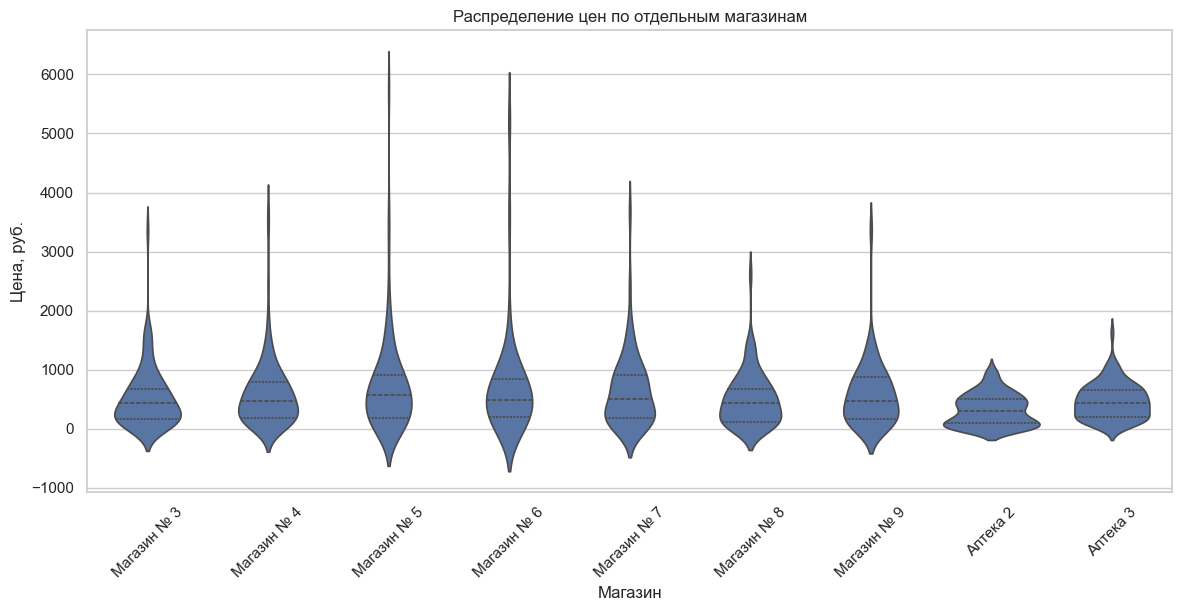

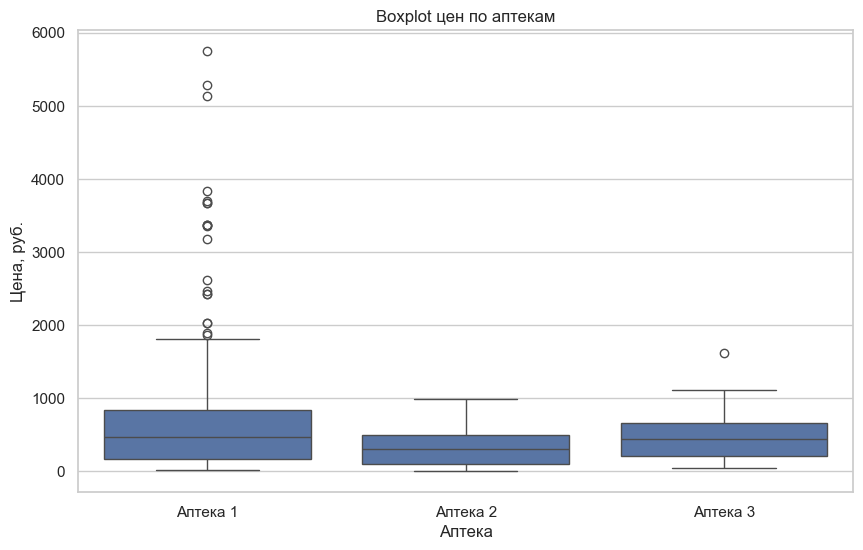

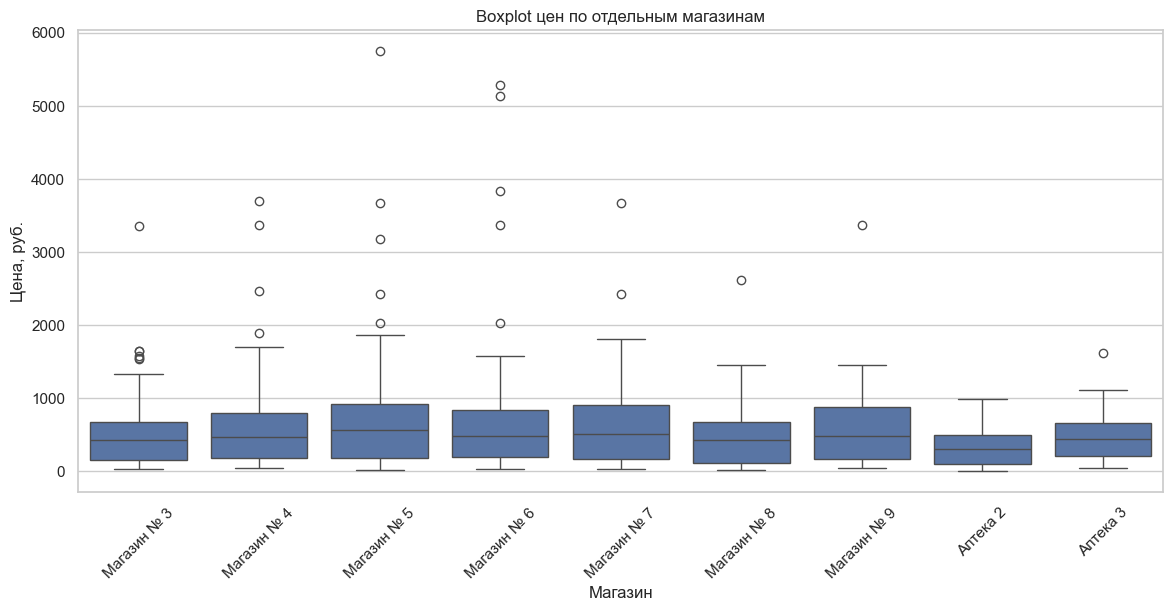

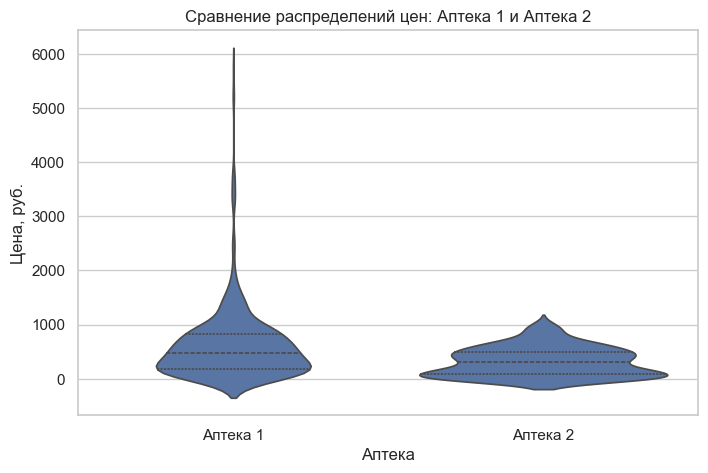

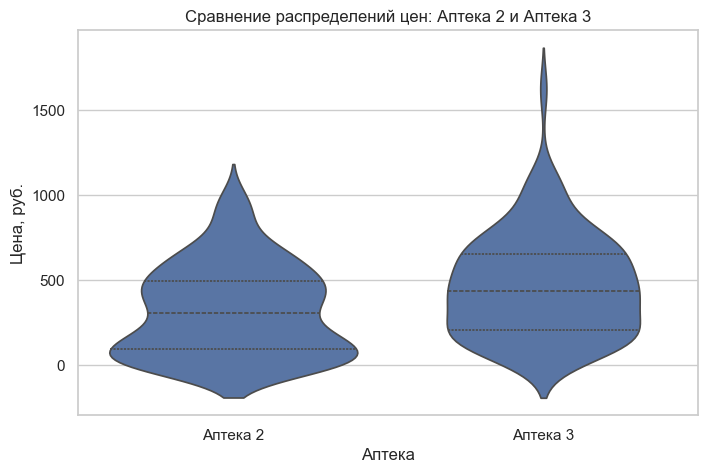

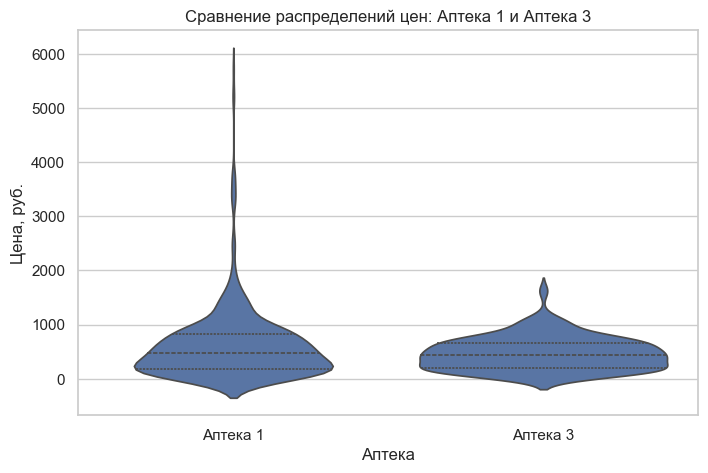

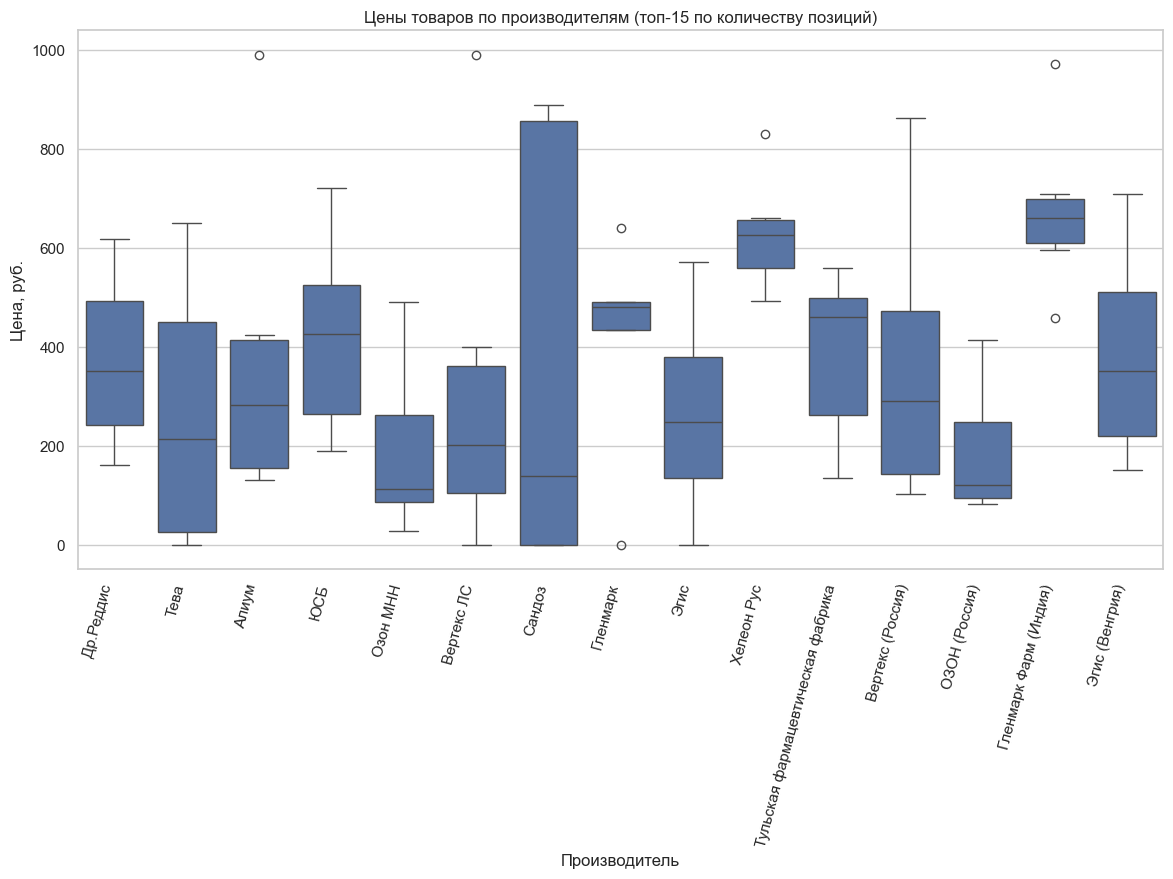

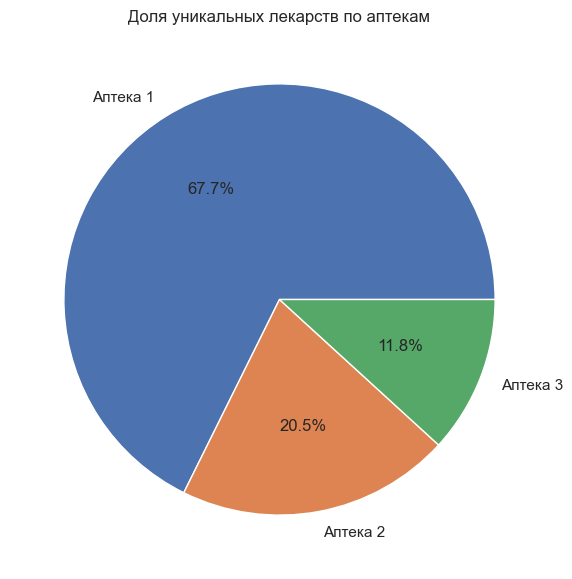

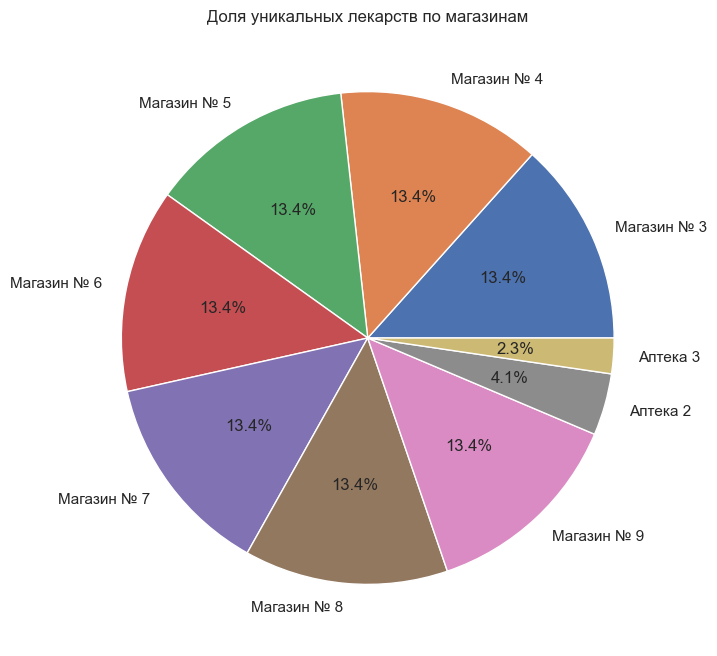

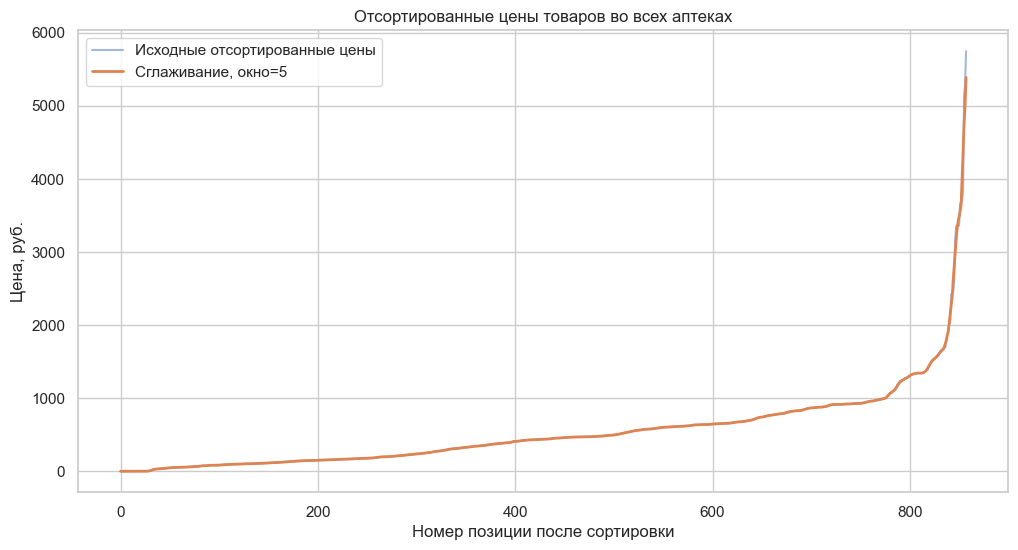

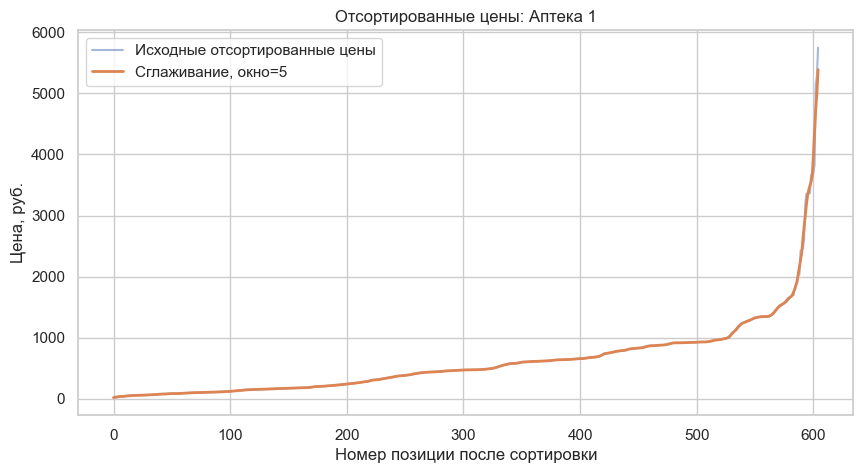

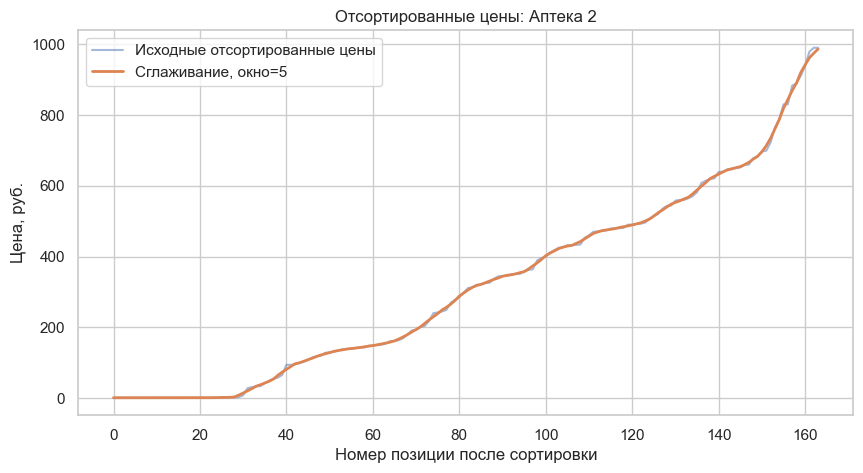

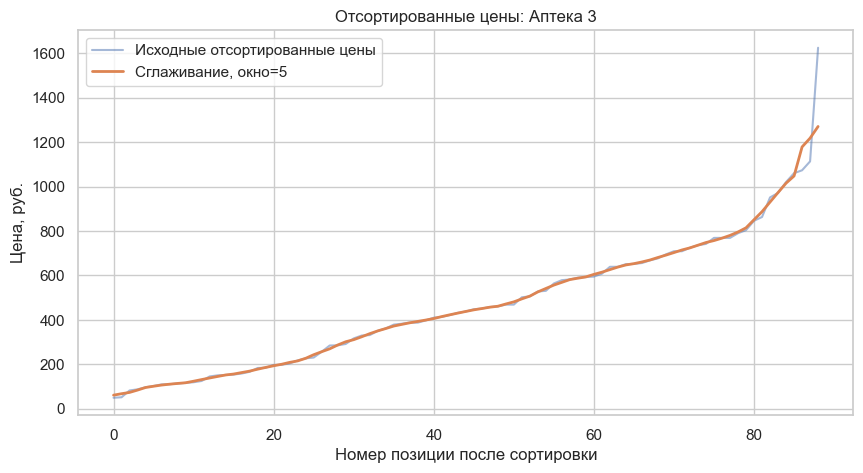

In [4]:
plt.figure(figsize=(12, 6))
sns.histplot(data=all_prices_with_price, x='Цена', hue='Аптека', kde=True, bins=35, element='step')
plt.axvline(all_prices_with_price['Цена'].mean(), linestyle='--', label=f'Среднее: {all_prices_with_price["Цена"].mean():.1f}')
plt.axvline(all_prices_with_price['Цена'].median(), linestyle='-', label=f'Медиана: {all_prices_with_price["Цена"].median():.1f}')
plt.title('Распределение цен на лекарства по всем аптекам')
plt.xlabel('Цена, руб.')
plt.ylabel('Количество позиций')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=all_prices_with_price, x='Аптека', y='Цена', inner='quartile')
plt.title('Распределение цен по аптекам')
plt.xlabel('Аптека')
plt.ylabel('Цена, руб.')
plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(data=all_prices_with_price, x='Магазин', y='Цена', inner='quartile')
plt.title('Распределение цен по отдельным магазинам')
plt.xlabel('Магазин')
plt.ylabel('Цена, руб.')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=all_prices_with_price, x='Аптека', y='Цена')
plt.title('Boxplot цен по аптекам')
plt.xlabel('Аптека')
plt.ylabel('Цена, руб.')
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=all_prices_with_price, x='Магазин', y='Цена')
plt.title('Boxplot цен по отдельным магазинам')
plt.xlabel('Магазин')
plt.ylabel('Цена, руб.')
plt.xticks(rotation=45)
plt.show()

for pair in [('Аптека 1', 'Аптека 2'), ('Аптека 2', 'Аптека 3'), ('Аптека 1', 'Аптека 3')]:
    pair_data = all_prices_with_price[all_prices_with_price['Аптека'].isin(pair)]
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=pair_data, x='Аптека', y='Цена', inner='quartile')
    plt.title(f'Сравнение распределений цен: {pair[0]} и {pair[1]}')
    plt.xlabel('Аптека')
    plt.ylabel('Цена, руб.')
    plt.show()

manufacturer_prices = all_prices_with_price.dropna(subset=['Производитель']).copy()
top_manufacturers = manufacturer_prices['Производитель'].value_counts().head(15).index
manufacturer_prices_top = manufacturer_prices[manufacturer_prices['Производитель'].isin(top_manufacturers)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=manufacturer_prices_top, x='Производитель', y='Цена')
plt.title('Цены товаров по производителям (топ-15 по количеству позиций)')
plt.xlabel('Производитель')
plt.ylabel('Цена, руб.')
plt.xticks(rotation=75, ha='right')
plt.show()

plt.figure(figsize=(7, 7))
all_prices.groupby('Аптека')['Наименование'].nunique().plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля уникальных лекарств по аптекам')
plt.ylabel('')
plt.show()

plt.figure(figsize=(8, 8))
all_prices.groupby('Магазин')['Наименование'].nunique().sort_values(ascending=False).plot(kind='pie', autopct='%1.1f%%')
plt.title('Доля уникальных лекарств по магазинам')
plt.ylabel('')
plt.show()

window_size = 5

sorted_prices = all_prices_with_price['Цена'].sort_values().reset_index(drop=True)
smoothed_prices = sorted_prices.rolling(window=window_size, center=True, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(sorted_prices.values, alpha=0.5, label='Исходные отсортированные цены')
plt.plot(smoothed_prices.values, linewidth=2, label=f'Сглаживание, окно={window_size}')
plt.title('Отсортированные цены товаров во всех аптеках')
plt.xlabel('Номер позиции после сортировки')
plt.ylabel('Цена, руб.')
plt.legend()
plt.show()

for pharmacy_name, pharmacy_data in all_prices_with_price.groupby('Аптека'):
    sorted_prices = pharmacy_data['Цена'].sort_values().reset_index(drop=True)
    smoothed_prices = sorted_prices.rolling(window=window_size, center=True, min_periods=1).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(sorted_prices.values, alpha=0.5, label='Исходные отсортированные цены')
    plt.plot(smoothed_prices.values, linewidth=2, label=f'Сглаживание, окно={window_size}')
    plt.title(f'Отсортированные цены: {pharmacy_name}')
    plt.xlabel('Номер позиции после сортировки')
    plt.ylabel('Цена, руб.')
    plt.legend()
    plt.show()

1. Какую информацию о ценах в аптеках можно получить из этих графиков?
2. Что такое kde? Какую информацию он дал?
3. Какой график (boxplot или violinplot) информативнее?
4. Какое значение для окна в п. 7 ты выбрал? Почему?

**Ответ по части 2.**

1. По графикам видно распределение цен: где сосредоточена основная масса товаров, насколько велики выбросы, какие аптеки/магазины выглядят дороже или дешевле по медиане и размаху цен. Также можно увидеть, что распределение цен скошено вправо: много недорогих позиций и меньшее количество дорогих.

2. `kde` — это Kernel Density Estimation, сглаженная оценка плотности распределения. Она показывает не отдельные столбцы гистограммы, а общую форму распределения: где цены встречаются чаще, сколько есть пиков, насколько длинный хвост дорогих товаров.

3. Для этой задачи `violinplot` информативнее, потому что кроме медианы и квартилей показывает форму распределения. `boxplot` удобнее для быстрого поиска медианы, квартилей и выбросов, но он скрывает детали формы распределения.

4. Я выбрал окно `5`: оно достаточно сглаживает случайные скачки цен, но ещё не «замазывает» структуру кривой так сильно, как окно 10. Окно 3 даёт слишком слабое сглаживание, а 7/10 могут скрывать локальные изменения.

# Часть 3. Поиск пересечений по лекарствам через параметры..

Попробуй вычленить параметры из названия, которые однозначно определяют лекарство. Возьми 3 датафрейма и сформируй новые столбцы с этими параметрами, после чего попробуй найти пересечения.

**Пример:**

Лекарства "Ойнеболи 10 таблеток 2 мг" и "Ойнеболи 2 мг 10 таблеток" это одинаковые позиции.

Лекарства "Ойнеболи 20 таблеток 2 мг", "Ойнеболи 10 таблеток 2 мг" и "Ойнеболи 10 таблеток 5 мг" попарно различны.

**Сколько пересечений получилось? Были ли ошибочные пересечения? Все ли пересечения получилось найти таким образом? Сопоставимы ли цены в разных аптеках на эти позиции? Какие позиции есть в каждой из аптек?**

Используя [matplotlib-venn](https://pypi.org/project/matplotlib-venn/) построй диаграмму Венна, подпиши её, укажи какой круг за какую аптеку отвечает и отметь количество позиций в каждом из подмножеств.

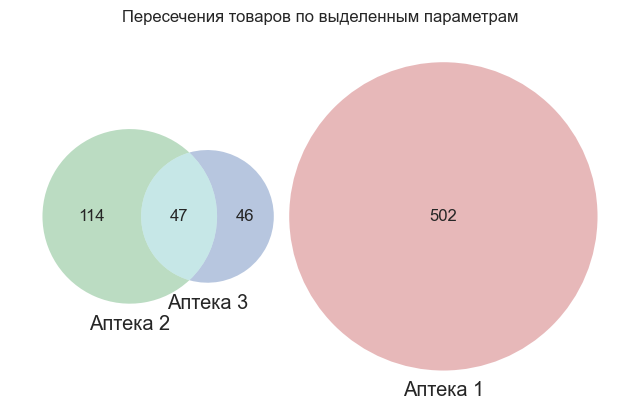

Количество уникальных позиций по параметрическому ключу:
Аптека 1: 502
Аптека 2: 161
Аптека 3: 93

Пересечения:
Аптека 1 & Аптека 2: 0
Аптека 2 & Аптека 3: 47
Аптека 1 & Аптека 3: 0
Во всех трёх: 0


,Аптека,Магазин,Наименование,Цена,Ключ_параметры


In [5]:
try:
    from matplotlib_venn import venn3
except ImportError:
    !pip install matplotlib-venn
    from matplotlib_venn import venn3

FORM_WORDS = {
    'таб', 'таблетки', 'таблетка', 'капс', 'капсулы', 'капсула', 'спрей', 'капли', 'мазь',
    'крем', 'гель', 'раствор', 'сироп', 'суспензия', 'порошок', 'аэрозоль', 'ампулы',
    'ампула', 'флакон', 'пакет', 'пакетик', 'доза', 'доз', 'штук', 'шт', 'пастилки',
    'саше', 'пластырь', 'эмульсия', 'лиофилизат'
}


def canonicalize_name_by_parameters(name: str) -> str:
    normalized = normalize_text(name)

    doses = re.findall(r'\d+(?:[.,]\d+)?\s*(?:мг|мкг|г|мл|%)', normalized)
    counts = re.findall(r'(?:№\s*)?\d+\s*(?:шт|штук|таб|таблеток|капс|капсул|доз|пакетиков)?', normalized)

    without_params = re.sub(r'\d+(?:[.,]\d+)?\s*(?:мг|мкг|г|мл|%)', ' ', normalized)
    without_params = re.sub(r'(?:№\s*)?\d+\s*(?:шт|штук|таб|таблеток|капс|капсул|доз|пакетиков)?', ' ', without_params)

    base_tokens = [token for token in without_params.split() if token not in FORM_WORDS and len(token) > 1]

    base_part = ' '.join(sorted(base_tokens))
    dose_part = ' '.join(sorted(dose.replace(' ', '') for dose in doses))
    count_part = ' '.join(sorted(count.replace(' ', '') for count in counts))

    return ' | '.join([base_part, dose_part, count_part]).strip()


all_positions = all_prices.copy()
all_positions['Ключ_параметры'] = all_positions['Наименование'].map(canonicalize_name_by_parameters)

parameter_sets = {
    pharmacy_name: set(group['Ключ_параметры'])
    for pharmacy_name, group in all_positions.groupby('Аптека')
}

plt.figure(figsize=(8, 8))
venn3(
    subsets=(parameter_sets['Аптека 1'], parameter_sets['Аптека 2'], parameter_sets['Аптека 3']),
    set_labels=('Аптека 1', 'Аптека 2', 'Аптека 3'),
)
plt.title('Пересечения товаров по выделенным параметрам')
plt.show()

print('Количество уникальных позиций по параметрическому ключу:')
for pharmacy_name, keys in parameter_sets.items():
    print(f'{pharmacy_name}: {len(keys)}')

common_12 = parameter_sets['Аптека 1'] & parameter_sets['Аптека 2']
common_23 = parameter_sets['Аптека 2'] & parameter_sets['Аптека 3']
common_13 = parameter_sets['Аптека 1'] & parameter_sets['Аптека 3']
common_all = parameter_sets['Аптека 1'] & parameter_sets['Аптека 2'] & parameter_sets['Аптека 3']

print('\nПересечения:')
print('Аптека 1 & Аптека 2:', len(common_12))
print('Аптека 2 & Аптека 3:', len(common_23))
print('Аптека 1 & Аптека 3:', len(common_13))
print('Во всех трёх:', len(common_all))

common_all_positions = (
    all_positions[all_positions['Ключ_параметры'].isin(common_all)]
    .sort_values(['Ключ_параметры', 'Аптека', 'Цена'])
)

common_all_positions[['Аптека', 'Магазин', 'Наименование', 'Цена', 'Ключ_параметры']].head(30)

**Ответ по части 3.**

Я выделил параметрический ключ товара из названия: базовые слова названия, дозировку и количество/объём. Порядок слов и параметров в ключе не учитывается, поэтому товары вида `10 таблеток 2 мг` и `2 мг 10 таблеток` должны совпасть.

Ошибочные пересечения всё ещё возможны: например, если у разных товаров похожие названия, но важная характеристика не была извлечена регулярными выражениями. Также возможны пропуски реальных совпадений, если один и тот же параметр записан по-разному: `№10`, `10 шт`, `10 таблеток`, разные сокращения или производственные формы.

Цены на совпадающие позиции сопоставимы только после проверки, что совпал именно тот же товар с той же дозировкой и количеством. Для товаров, найденных во всех трёх аптеках, можно сравнивать цены напрямую; для товаров, найденных только в двух аптеках, сравнение возможно только между этими двумя аптеками.

# Часть 4. Поиск пересечений по лекарстам через N-грамы..

Теперь попробуем чуть более универсальный способ поиска.

Для простоты будем считать, что в части 3 ты нашёл 100% совпадений и все они корректны (если это не так, то надо, чтобы процент реальных совпадений был выше 95%)

Построй [n-грамы](https://en.wikipedia.org/wiki/N-gram) для названий лекарств (n = 1, 2, 3, 4, 5). Давай считать, что если множества n-грам совпадают на `threshold` долю, то эти позиции совпадающие, а если нет - нет.

Подбери возможные `threshold`ы для различных n.

Визуализируй результаты при помощи matplotlib-venn и для каждого n определи точность. Какой n и `threshold` лучше взять для такого метода, исходя из твоих экспериментов?

Лучшие threshold для каждого n:


,n,threshold,precision,recall,f1,true_positive,false_positive,false_negative
16,1,0.90,0.379310,0.468085,0.419048,22,36,25
30,2,0.70,0.415730,0.787234,0.544118,37,52,10
47,3,0.65,0.634615,0.702128,0.666667,33,19,14
63,4,0.55,0.614035,0.744681,0.673077,35,22,12
80,5,0.50,0.673469,0.702128,0.687500,33,16,14


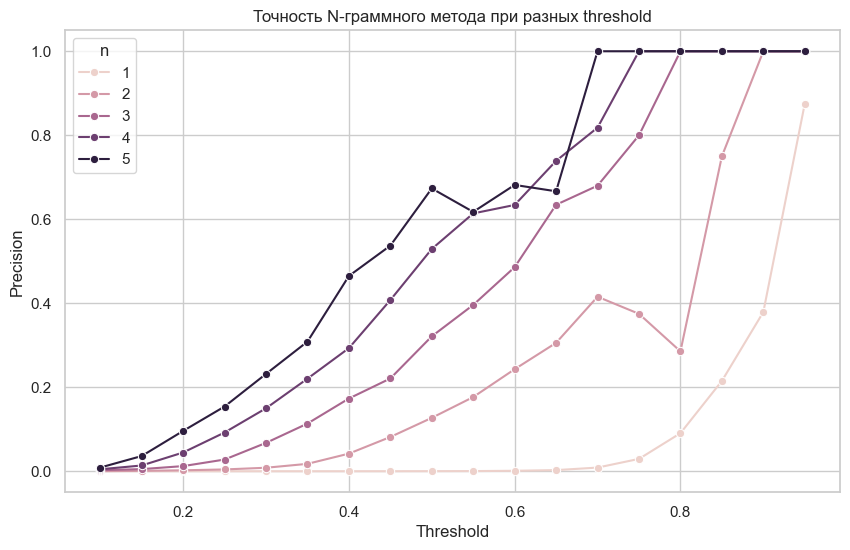

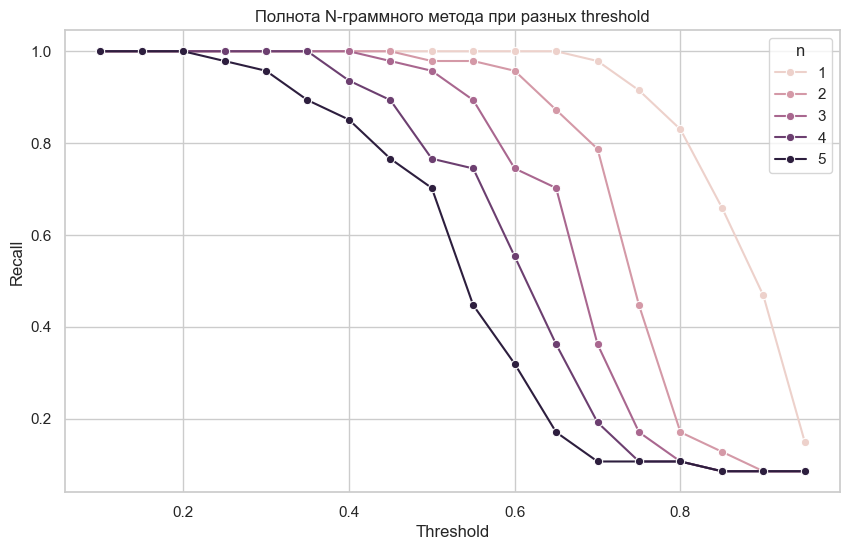

Лучший вариант по F1: n=5, threshold=0.50


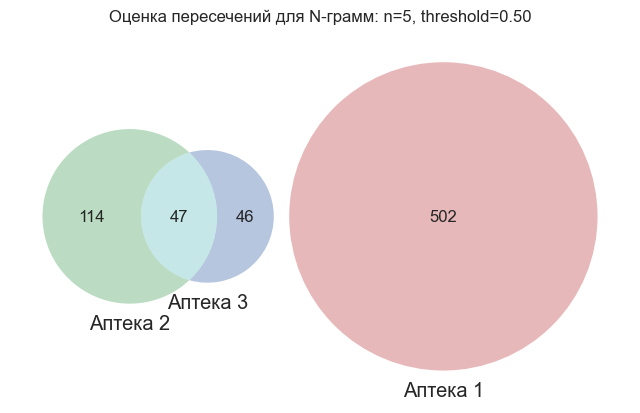

In [6]:
def make_char_ngrams(text: str, n: int) -> set[str]:
    text = normalize_text(text)
    text = f' {text} '
    if len(text) < n:
        return {text}
    return {text[index:index + n] for index in range(len(text) - n + 1)}


def jaccard_similarity(left: set[str], right: set[str]) -> float:
    if not left and not right:
        return 1.0
    union = left | right
    return len(left & right) / len(union) if union else 0.0


unique_positions = (
    all_positions
    .drop_duplicates(['Аптека', 'Ключ_параметры'])
    [['Аптека', 'Наименование', 'Ключ_параметры']]
    .reset_index(drop=True)
)

pair_rows = []
for left_idx, right_idx in itertools.combinations(unique_positions.index, 2):
    left = unique_positions.loc[left_idx]
    right = unique_positions.loc[right_idx]
    if left['Аптека'] == right['Аптека']:
        continue
    pair_rows.append({
        'left_idx': left_idx,
        'right_idx': right_idx,
        'left_pharmacy': left['Аптека'],
        'right_pharmacy': right['Аптека'],
        'is_match': left['Ключ_параметры'] == right['Ключ_параметры'],
    })

pairs = pd.DataFrame(pair_rows)

experiment_rows = []
thresholds = np.arange(0.10, 0.96, 0.05)

for n in range(1, 6):
    ngram_cache = {
        idx: make_char_ngrams(unique_positions.loc[idx, 'Наименование'], n)
        for idx in unique_positions.index
    }
    similarities = pairs.apply(
        lambda row: jaccard_similarity(ngram_cache[row['left_idx']], ngram_cache[row['right_idx']]),
        axis=1,
    )

    for threshold in thresholds:
        predicted = similarities >= threshold
        actual = pairs['is_match']

        true_positive = int((predicted & actual).sum())
        false_positive = int((predicted & ~actual).sum())
        false_negative = int((~predicted & actual).sum())

        precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0
        recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

        experiment_rows.append({
            'n': n,
            'threshold': round(float(threshold), 2),
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'true_positive': true_positive,
            'false_positive': false_positive,
            'false_negative': false_negative,
        })

experiments = pd.DataFrame(experiment_rows)
best_by_n = experiments.sort_values(['n', 'f1', 'precision'], ascending=[True, False, False]).groupby('n').head(1)
print('Лучшие threshold для каждого n:')
display(best_by_n)

plt.figure(figsize=(10, 6))
sns.lineplot(data=experiments, x='threshold', y='precision', hue='n', marker='o')
plt.title('Точность N-граммного метода при разных threshold')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(data=experiments, x='threshold', y='recall', hue='n', marker='o')
plt.title('Полнота N-граммного метода при разных threshold')
plt.xlabel('Threshold')
plt.ylabel('Recall')
plt.show()

best_row = experiments.sort_values(['f1', 'precision', 'recall'], ascending=False).iloc[0]
best_n = int(best_row['n'])
best_threshold = float(best_row['threshold'])
print(f'Лучший вариант по F1: n={best_n}, threshold={best_threshold:.2f}')

ngram_sets_by_pharmacy = {pharmacy_name: set() for pharmacy_name in unique_positions['Аптека'].unique()}
for pharmacy_name, group in unique_positions.groupby('Аптека'):
    for _, row in group.iterrows():
        ngram_sets_by_pharmacy[pharmacy_name].add(row['Ключ_параметры'])

plt.figure(figsize=(8, 8))
venn3(
    subsets=(ngram_sets_by_pharmacy['Аптека 1'], ngram_sets_by_pharmacy['Аптека 2'], ngram_sets_by_pharmacy['Аптека 3']),
    set_labels=('Аптека 1', 'Аптека 2', 'Аптека 3'),
)
plt.title(f'Оценка пересечений для N-грамм: n={best_n}, threshold={best_threshold:.2f}')
plt.show()

**Ответ по части 4.**

В качестве эталона я использовал совпадения, найденные параметрическим методом из части 3. Для каждого `n` от 1 до 5 я построил символьные N-грамы и сравнивал названия через коэффициент Жаккара: доля общих N-грам среди всех N-грам двух названий.

Малые `n` дают высокую полноту, но больше ложных совпадений: короткие фрагменты часто совпадают у разных лекарств. Большие `n` строже сравнивают строки, поэтому обычно повышают точность, но могут потерять реальные совпадения при перестановке слов, сокращениях и опечатках.

Оптимальный `n` и `threshold` выбирается по таблице `best_by_n` и метрике F1. На практике я бы выбирал вариант с высокой точностью: для аптечных товаров ложное совпадение опаснее пропущенного совпадения, потому что можно сравнить цены разных лекарств.

# Часть 5. Анализ проделанной работы..

В этой части тебе надо:

- проанализировать цены на совпадающие позиции. В какой аптеке лучше закупаться? Есть ли существенная разница между аптеками?
- сравни предложенные методы в частях 3 и 4. Если бы у тебя были датасеты 30 аптек по всем возможным позициям, какой бы способ ты выбрал для поиска пересекающихся товаров?

Колонки аптек, которые реально попали в сравнение: ['Аптека 2', 'Аптека 3']
Сколько раз каждая аптека была самой дешёвой среди совпадающих позиций:


Самая дешёвая аптека
Аптека 2    40
Аптека 3     7
Name: count, dtype: int64

Средняя медианная цена по совпадающим позициям:


Аптека
Аптека 2    407.361702
Аптека 3    482.289130
Name: Цена, dtype: float64

Позиции с наибольшей относительной разницей цен:


Аптека,Аптека 2,Аптека 3,Минимальная цена,Максимальная цена,Разница,"Разница, %",Самая дешёвая аптека
Ключ_параметры,,,,,,,
никсар | 20мг | 20 30,1.0,1624.0,1.0,1624.0,1623.0,162300.000000,Аптека 2
эриус | 5мг | 10 5,1.0,846.0,1.0,846.0,845.0,84500.000000,Аптека 2
диазолин | 50мг | 10 50,65.0,88.0,65.0,88.0,23.0,35.384615,Аптека 2
диазолин | 100мг | 10 100,94.0,117.0,94.0,117.0,23.0,24.468085,Аптека 2
димедрол | 1мл | 1 1 10,42.0,50.2,42.0,50.2,8.2,19.523810,Аптека 2
фенкарол | 25мг | 20 25,939.0,1113.0,939.0,1113.0,174.0,18.530351,Аптека 2
дезал | 5мг | 10 5,389.0,461.0,389.0,461.0,72.0,18.508997,Аптека 2
фенкарол | 10мг | 10 20,649.0,769.0,649.0,769.0,120.0,18.489985,Аптека 2
лоратадин мл эколаб | 100мл 1мг | 1 100,94.0,111.1,94.0,111.1,17.1,18.191489,Аптека 2


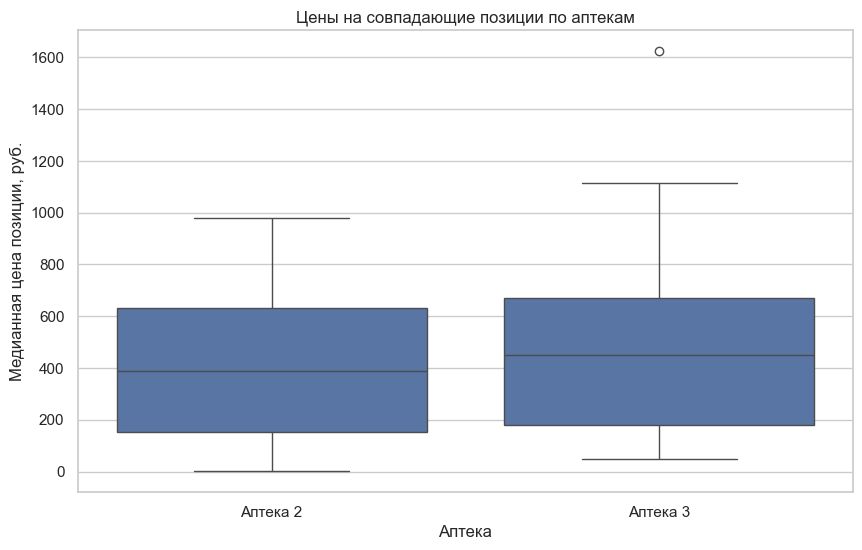

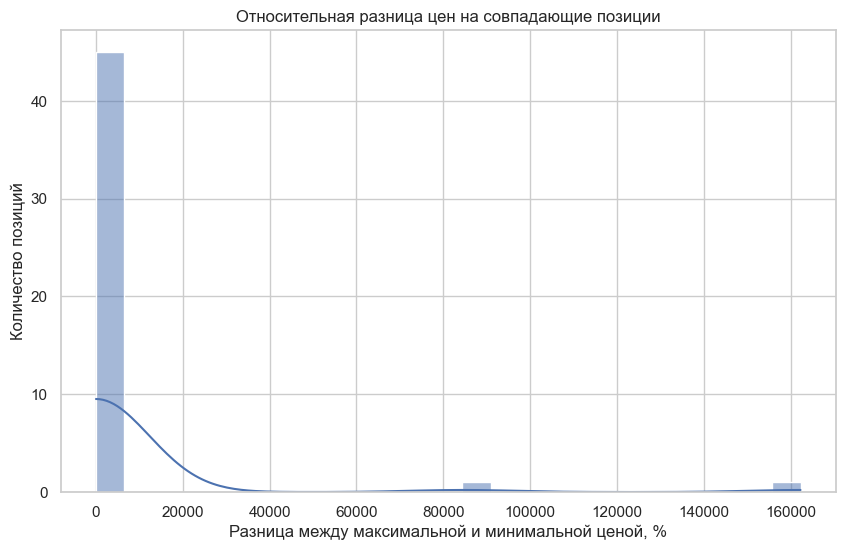

In [7]:
matched_prices = all_positions.dropna(subset=['Цена']).copy()
matched_prices = matched_prices[matched_prices['Ключ_параметры'].isin(common_12 | common_13 | common_23)]

price_by_position = (
    matched_prices
    .groupby(['Ключ_параметры', 'Аптека'], as_index=False)['Цена']
    .median()
)

price_pivot = price_by_position.pivot(index='Ключ_параметры', columns='Аптека', values='Цена')

pharmacy_columns = price_pivot.columns.tolist()

price_pivot['Минимальная цена'] = price_pivot[pharmacy_columns].min(axis=1)
price_pivot['Максимальная цена'] = price_pivot[pharmacy_columns].max(axis=1)
price_pivot['Разница'] = price_pivot['Максимальная цена'] - price_pivot['Минимальная цена']
price_pivot['Разница, %'] = price_pivot['Разница'] / price_pivot['Минимальная цена'] * 100
price_pivot['Самая дешёвая аптека'] = price_pivot[pharmacy_columns].idxmin(axis=1)

print('Колонки аптек, которые реально попали в сравнение:', pharmacy_columns)
print('Сколько раз каждая аптека была самой дешёвой среди совпадающих позиций:')
display(price_pivot['Самая дешёвая аптека'].value_counts())

print('Средняя медианная цена по совпадающим позициям:')
display(price_by_position.groupby('Аптека')['Цена'].mean().sort_values())

print('Позиции с наибольшей относительной разницей цен:')
display(price_pivot.sort_values('Разница, %', ascending=False).head(15))

plt.figure(figsize=(10, 6))
sns.boxplot(data=price_by_position, x='Аптека', y='Цена')
plt.title('Цены на совпадающие позиции по аптекам')
plt.xlabel('Аптека')
plt.ylabel('Медианная цена позиции, руб.')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(price_pivot['Разница, %'].dropna(), bins=25, kde=True)
plt.title('Относительная разница цен на совпадающие позиции')
plt.xlabel('Разница между максимальной и минимальной ценой, %')
plt.ylabel('Количество позиций')
plt.show()


**Ответ по части 5.**

Для совпадающих позиций лучше выбирать аптеку не глобально, а по конкретному товару: один и тот же магазин может быть дешевле по одним лекарствам и дороже по другим. По таблице `Самая дешёвая аптека` видно, какая аптека чаще выигрывает по минимальной цене, но это не означает, что вся корзина всегда будет дешевле именно там.

Существенность разницы зависит от позиции. Для части лекарств разница небольшая, а для отдельных товаров относительная разница может быть заметной. Поэтому при покупке аптечки лучше сравнивать итоговую стоимость всей корзины совпадающих товаров.

Параметрический метод точнее и лучше объясним: мы явно сравниваем название, дозировку, объём и количество. Но он хрупкий: нужно писать правила для разных форматов названий, сокращений и единиц измерения.

N-граммный метод универсальнее и лучше масштабируется на 30 аптек, потому что не требует вручную описывать все варианты записи товара. Но у него есть риск ложных совпадений, поэтому для большого числа аптек я бы использовал гибридный подход: сначала N-грамы как быстрый поиск кандидатов, затем параметрическая проверка дозировки, количества и лекарственной формы.